In [55]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [56]:
from graph_utils import convert_graphrag_format,clean_graphrag_format,graph_stats,deg_hist,print_neighbors

In [57]:
from graph_utils import BookSearcher
from graph_utils import sample_pairs

In [66]:
import json
with open('../output/graphs/anony_chs_new.json', 'r',encoding="utf-8") as file:
    # Use json.load() to convert the file's content to a Python dictionary
    data = json.load(file)

In [67]:
graph = clean_graphrag_format(data)
graph_complete = clean_graphrag_format(data,remove_unclassed_entity=False)
G = nx.node_link_graph(graph,edges="links")
G_complete = nx.node_link_graph(graph_complete,edges="links")

In [68]:
graph_complete['links'][0]

{'source': 'PERSON#755',
 'target': '身份: 皇帝',
 'name': 'has_attribute',
 'value': 1}

In [75]:
graph_stats(G_complete)

Number of Nodes:33999
Number of edges:87242
Degree stats: mean=5.132033295096915, median=1.0, lower_quantile=1.0, higher_quantile=2.0, std=44.720524355396755
Degree counts:
0        1
1    20230
2     6767
3     2211
4     1088
Name: count, dtype: int64
...
1340    1
1483    1
1527    1
3428    1
3863    1
Name: count, dtype: int64
Multigraph detected. Skipping clustering coef
Graph is not connected. Numer of components: 63


In [72]:
import networkx as nx
import time
import random

# 2. Select a few random nodes to act as our "seed" nodes
# seed_nodes = random.sample(list(G_complete.nodes()), 10)
# seed_nodes = ['PERSON#924', '宝刀', '官府','LOCATION#12','LOCATION#60','LOCATION#35','LOCATION#78']
seed_nodes = ['PERSON#924', '宝刀','LOCATION#12','LOCATION#60','LOCATION#35','LOCATION#78']
print(f"Seed nodes: {seed_nodes}")

# 3. Set up the personalization dictionary
# Seed nodes get a weight of 1; all others default to 0. 
# NetworkX automatically normalizes these to sum to 1.0.
personalization_dict = {node: 0 for node in G_complete.nodes()}
for node in seed_nodes:
    personalization_dict[node] = 1

# 4. Run and time the RWR / Personalized PageRank
print("Running Personalized PageRank...")
start_time = time.time()

# alpha=0.85 means an 85% chance to traverse an edge, 15% chance to restart at seeds
rwr_scores = nx.pagerank(G_complete, alpha=0.50, personalization=personalization_dict)

end_time = time.time()
execution_time = end_time - start_time

# 5. Output results
print(f"Done! Calculated scores for all {len(rwr_scores)} nodes.")
print(f"Execution time: {execution_time:.4f} seconds")

# Optional: Print the top 10 highest scoring nodes
top_nodes = sorted(rwr_scores.items(), key=lambda x: x[1], reverse=True)[:10]
print(f"Top 3 nodes by score: {top_nodes}")

Seed nodes: ['PERSON#924', '宝刀', 'LOCATION#12', 'LOCATION#60', 'LOCATION#35', 'LOCATION#78']
Running Personalized PageRank...
Done! Calculated scores for all 33999 nodes.
Execution time: 0.7161 seconds
Top 3 nodes by score: [('PERSON#924', 0.16357951634928547), ('LOCATION#60', 0.13825446073201433), ('LOCATION#78', 0.13515977689374345), ('宝刀', 0.13319153375449783), ('PERSON#699', 0.03607014759763904), ('PERSON#974', 0.015844156975286686), ('PERSON#904', 0.011386660519092628), ('PERSON#17', 0.011288053369969282), ('PERSON#622', 0.010961181260263776), ('PERSON#152', 0.010664770502463327)]


In [73]:
# 4. Calculate edge scores (defined as score(u) + score(v))
start_time = time.time()
edge_scores = {}
for u, v in G_complete.edges():
    edge_scores[(u, v)] = rwr_scores[u]*rwr_scores[v]*100

# 5. Sort to find the top 10 edges
top_10_edges = sorted(edge_scores.items(), key=lambda item: item[1], reverse=True)[:50]

end_time = time.time()

# 6. Output results
print(f"Execution time: {end_time - start_time:.4f} seconds\n")

print("Top 10 most relevant edges:")
for i, (edge, score) in enumerate(top_10_edges, 1):
    for e in graph_complete['links']:
        if e['source'] == edge[0] and e['target'] == edge[1]:
            print(f"{i}. Edge {e} - Score: {score:.6f}")

Execution time: 0.2204 seconds

Top 10 most relevant edges:
1. Edge {'source': 'PERSON#924', 'target': 'PERSON#924', 'name': 'represented_by', 'value': 1} - Score: 2.675826
1. Edge {'source': 'PERSON#924', 'target': 'PERSON#924', 'name': 'kw_filter_by', 'value': 1} - Score: 2.675826
2. Edge {'source': 'PERSON#924', 'target': 'LOCATION#60', 'name': '前往', 'value': 1} - Score: 2.261560
2. Edge {'source': 'PERSON#924', 'target': 'LOCATION#60', 'name': '呈上', 'value': 1} - Score: 2.261560
3. Edge {'source': 'PERSON#924', 'target': '宝刀', 'name': '拥有', 'value': 1} - Score: 2.178741
3. Edge {'source': 'PERSON#924', 'target': '宝刀', 'name': '售卖', 'value': 1} - Score: 2.178741
4. Edge {'source': '宝刀', 'target': 'LOCATION#60', 'name': '被送至', 'value': 1} - Score: 1.841432
6. Edge {'source': 'PERSON#699', 'target': 'LOCATION#60', 'name': '被押至', 'value': 1} - Score: 0.498686
6. Edge {'source': 'PERSON#699', 'target': 'LOCATION#60', 'name': '位于', 'value': 1} - Score: 0.498686
6. Edge {'source': 'PERSON

In [49]:
edge
for e in graph_complete['links']:
    if e['source'] == edge[0] and e['target'] == edge[1]:
        print(e)

{'source': 'PERSON#924', 'target': 'PERSON#434', 'name': '提及', 'value': 1}


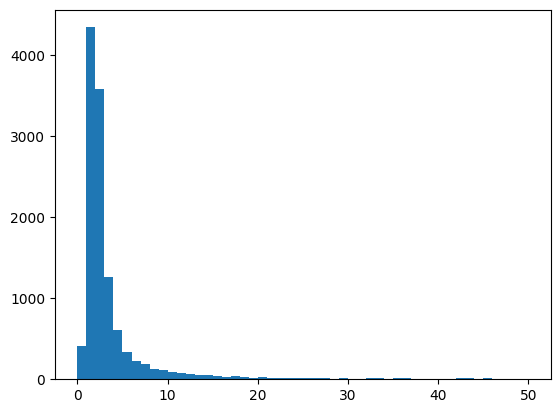

In [42]:
deg_hist(G)

In [ ]:
list(G.nodes)[:10]

In [ ]:
sorted(G.degree,key=lambda x:x[1],reverse=True)[:50]

In [95]:
# node = sorted(G.degree,key=lambda x:x[1],reverse=True)[9][0]
node = '陈巧倩'
print("node name: "+node)
print_neighbors(G_complete,node)

node name: 陈巧倩
Number of neighbors: 11
Neighbor: 韩立, Contents: {'name': '韩立', 'category': 'keyword', 'symbolSize': 25, 'properties': {'name': '韩立'}}, Edge: {0: {'name': 'related_to', 'value': 1}}
Neighbor: 性别: 女, Contents: {'name': '性别: 女', 'category': 'attribute', 'symbolSize': 25, 'properties': {'name': '性别: 女', 'chunk id': 'jQlMLG0I'}}, Edge: {0: {'name': 'has_attribute', 'value': 1}}
Neighbor: 身份/职位: 陈师妹（师门关系）, Contents: {'name': '身份/职位: 陈师妹（师门关系）', 'category': 'attribute', 'symbolSize': 25, 'properties': {'name': '身份/职位: 陈师妹（师门关系）', 'chunk id': 'H7dumlwT'}}, Edge: {0: {'name': 'has_attribute', 'value': 1}}
Neighbor: 性格: 冷艳、傲然、态度冷漠, Contents: {'name': '性格: 冷艳、傲然、态度冷漠', 'category': 'attribute', 'symbolSize': 25, 'properties': {'name': '性格: 冷艳、傲然、态度冷漠', 'chunk id': 'H7dumlwT'}}, Edge: {0: {'name': 'has_attribute', 'value': 1}}
Neighbor: 关系特征: 曾与韩立有肌肤之亲（文中提及）, Contents: {'name': '关系特征: 曾与韩立有肌肤之亲（文中提及）', 'category': 'attribute', 'symbolSize': 25, 'properties': {'name': '关系特征: 曾与韩立有肌肤之亲

In [26]:
graph.keys()

dict_keys(['nodes', 'links', 'categories', 'stats'])

In [56]:
nodes_df=pd.DataFrame(graph['nodes'])
nodes_df

,id,name,category,symbolSize,properties
0,韩立,韩立,keyword,25,{'name': '韩立'}
1,余子童的元神,余子童的元神,concept,25,"{'name': '余子童的元神', 'chunk id': '26OazkQN', 'sc..."
2,墨大夫的尸体,墨大夫的尸体,biological_entity,25,"{'name': '墨大夫的尸体', 'chunk id': '26OazkQN', 'sc..."
3,示范储物袋使用,示范储物袋使用,event,25,"{'name': '示范储物袋使用', 'chunk id': '-AXUAE3Y', 's..."
4,引见传功弟子事件,引见传功弟子事件,keyword,25,{'name': '引见传功弟子事件'}
...,...,...,...,...,...
3032,火焰小狗,火焰小狗,object,25,"{'name': '火焰小狗', 'chunk id': 'i5LCwrEp', 'sche..."
3033,火蛇,火蛇,object,25,"{'name': '火蛇', 'chunk id': 'i5LCwrEp', 'schema..."
3034,火焰小马,火焰小马,object,25,"{'name': '火焰小马', 'chunk id': 'i5LCwrEp', 'sche..."
3035,童景的仙根(珍稀),童景的仙根(珍稀),concept,25,"{'name': '童景的仙根(珍稀)', 'chunk id': 'i5LCwrEp', ..."


In [33]:
graph['links']

[{'source': '韩立', 'target': '余子童的元神', 'name': 'attacks', 'value': 1},
 {'source': '韩立', 'target': '余子童的元神', 'name': 'kills', 'value': 1},
 {'source': '韩立', 'target': '墨大夫的尸体', 'name': 'searches', 'value': 1},
 {'source': '韩立', 'target': '示范储物袋使用', 'name': 'participates_in', 'value': 1},
 {'source': '韩立', 'target': '引见传功弟子事件', 'name': 'participates_in', 'value': 1},
 {'source': '韩立', 'target': '领取杂务工作', 'name': 'participates_in', 'value': 1},
 {'source': '韩立',
  'target': '选择青石岭百药园任务',
  'name': 'participates_in',
  'value': 1},
 {'source': '韩立', 'target': '青叶法器', 'name': 'used_by', 'value': 1},
 {'source': '韩立', 'target': '飞行练习', 'name': 'participates_in', 'value': 1},
 {'source': '韩立', 'target': '百机堂', 'name': 'arrives_in', 'value': 1},
 {'source': '韩立', 'target': '火弹术', 'name': 'uses', 'value': 1},
 {'source': '韩立', 'target': '火弹术', 'name': 'displayed', 'value': 1},
 {'source': '韩立', 'target': '火弹术', 'name': 'related_to', 'value': 1},
 {'source': '韩立', 'target': '侏儒', 'name': 'kills'

In [21]:
components = sorted(nx.connected_components(internal_graph), key=len, reverse=True)
principal_nodes = list(components[0])

In [30]:

principal_component = internal_graph.subgraph(principal_nodes)
graph_stats(principal_component)

Number of Nodes:902
Number of edges:1852
Degree stats: mean=4.106430155210643, median=2.0, lower_quantile=1.0, higher_quantile=3.0, std=15.436446727632221
Degree counts:
1    444
2    172
3     77
4     44
5     21
Name: count, dtype: int64
...
40     1
41     1
47     1
90     1
427    1
Name: count, dtype: int64
Clustering coef (called transitivity in networkx):0.03689655172413793
Diameter: 8


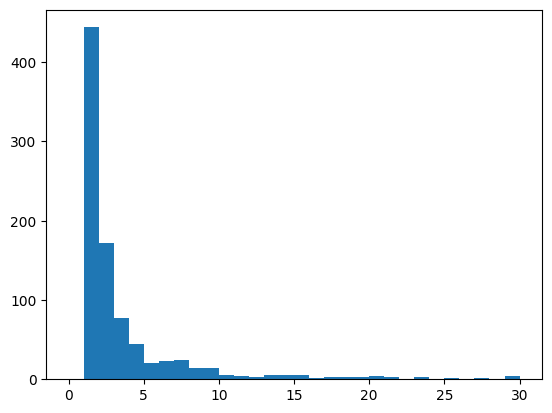

In [51]:
deg_hist(principal_component,bins=30,limit=30)

In [18]:
[len(c) for c in sorted(nx.connected_components(internal_graph), key=len, reverse=True)][:5]

[902, 81, 19, 10, 8]

In [22]:
principal_component=sorted(nx.connected_components(internal_graph), key=len, reverse=True)[0]
type(principal_component)

set

In [24]:
internal_graph.subgraph(principal_component)

In [23]:
type(internal_graph)

networkx.classes.graph.Graph

In [8]:
for node in list(internal_graph.nodes(data=False))[320:330]:
    print(f"node:{node}\ndata:{data}\n")

node:"BAZAAR"
data:

node:"YUN MIAOQING"
data:

node:"ZHAO XUHE"
data:

node:"TALISMANIC ARTS"
data:

node:"HUIREN REVERSE FIRE TALISMAN"
data:

node:"GOLDEN LIGHT TALISMAN"
data:

node:"FIVE THUNDER TALISMAN"
data:

node:"SWORD QI TALISMAN"
data:

node:"WANLING BANNER"
data:

node:"积阴傀儡"
data:



In [ ]:
for edge in list(internal_graph.edges(data=False))[500:510]:
    print(f"edge:{edge}\n")

In [40]:
node = '"LU YANG"'
linked_edges = []
for edge in list(internal_graph.edges(data=True)):
    if node in edge[0] or node in edge[1]:
        linked_edges.append(edge)
for edge in linked_edges[:20]:
    print(edge)

('"QIN TIANHE"', '"LU YANG"', {'weight': 6.0, 'description': '"Qin Tianhe mistakenly honors Lu Yang as a \'真人\' due to Lu Yang’s powerful presence."', 'source_id': 'chunk-a948dd531e02b271eb4a4e19151291fa', 'order': 1})
('"LU YANG"', '"CHONGGUANG ZHENREN"', {'weight': 7.0, 'description': '"Lu Yang is under a mission to meet Chongguang Zhenren, indicating a hierarchical responsibility."', 'source_id': 'chunk-a948dd531e02b271eb4a4e19151291fa', 'order': 1})
('"LU YANG"', '"HOLY SECT"', {'weight': 9.0, 'description': '"Lu Yang holds a high status within the Holy Sect, implied by his task and powers."', 'source_id': 'chunk-a948dd531e02b271eb4a4e19151291fa', 'order': 1})


In [39]:
keyword = '补天峰'
related_nodes = {}
for node, data in list(internal_graph.nodes(data=True)):
    if keyword in node:
        related_nodes[node] = data
for node, data in list(related_nodes.items())[:20]:
    print(node)
    edges_text = ''
    counts = 0
    for edge in internal_graph.edges():
        if edge[0] == node:
            edges_text += edge[1]
            edges_text += ', '
            counts += 1
        if edge[1] == node:
            edges_text += edge[0]
            edges_text += ', '
            counts += 1
    edges_text += str(counts)
    print(edges_text+'\n')
    
    

"补天峰顶"
"赵旭河", 1

"补天峰峰主"
"补天峰", 1

"圣宗补天峰"
"吕阳", "骷髅山", 2

"补天峰的秘术"
"补天峰主", "吕阳", 2

"补天峰主的分神"
0

"补天峰主 陈太合"
"阴阳图箓道基", 1

"补天峰"
"合欢殿", "藏书阁", "善功楼", "补天峰峰主", "宴席", "碧飞鸢", "圣宗真人", "若湘", "吕阳", "初圣宗", "刘信", "陈信安", "补天峰主", "萧石叶", "伏龙罗汉", "圣宗", "圣火崖", "元屠", "乌苍", "阿鼻剑", 20

"补天峰主"
"盘龙岛", "正魔大战", "倩儿", "盗天机", "金丹剑气", "九天都箓秘魔阴雷", "土块", "幽祖师", "阴阳大道图", "阴阳混洞太玄神光", "坐山君", "赤鱬鳞", "庚金", "盘龙", "伏龙", "舒倩", "圣宗真人", "避风丹", "补天峰的秘术", "天雷", "劫数", "夫人", "云家老祖魂魄", "替劫秘术", "接天云海", "赵旭河", "补天峰", "刘信", "初圣宗", "圣宗", "吕阳", "若湘夫人", "陈舒倩", "听幽祖师", "陈信安", "鸿运道人", "阎魔殿", "伏龙罗汉", "陆元淳", "重光", "巫鬼秘境", "骷髅山", "素女", "重光真人", "阴山真人", "巫鬼道", "元屠", 47



Todo:
 - Find a graph pretty print method
 - Research the "ontology for novel understanding", find something better than knowledge graph to handle temporal and evolving information
 - Research knowledge graph completion/merge techniques, and hierachical knowledge graph approaches.

In [23]:
## Below is for 559 assignment 2

import matplotlib.pyplot as plt

<>:24: SyntaxWarning: invalid escape sequence '\l'
<>:24: SyntaxWarning: invalid escape sequence '\l'
C:\Users\emper\AppData\Local\Temp\ipykernel_34352\4030586553.py:24: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f'Poisson Distribution PMF ($\lambda = {lam}$)')


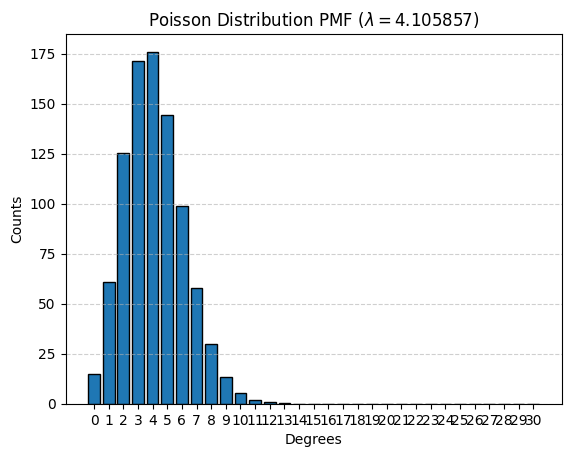

In [52]:
n=902
p=0.004557

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Parameter
lam = (n-1)*p  # The average number of events (lambda)

# Define the range of k values
# Since Poisson can go to infinity, we usually plot up to lam + ~4 standard deviations
# standard deviation of Poisson is sqrt(lambda)
k_max = 30
k = np.arange(0, k_max + 1)

# Calculate the PMF for each k
pmf_values = poisson.pmf(k, lam)*902

# Create the bar plot
plt.bar(k, pmf_values, edgecolor='black')

# Formatting
plt.title(f'Poisson Distribution PMF ($\lambda = {lam}$)')
plt.xlabel('Degrees')
plt.ylabel('Counts')
plt.xticks(k)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

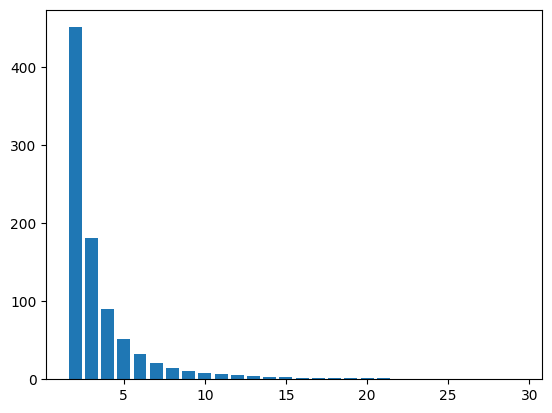

In [55]:
k = np.arange(2,30)
c=2
probs =2*c*(c+1)/k/(k+1)/(k+2)
counts = probs*902
plt.bar(k, counts)
plt.show()

In [56]:
g = principal_component

In [160]:
list(g.edges)[:50]

[('"玄冥府君相"', '"听幽祖师"'),
 ('"元气大丹"', '"吕阳"'),
 ('"千年大劫"', '"重光真人"'),
 ('"清澄飞雪真君"', '"界天"'),
 ('"清澄飞雪真君"', '"净土真君"'),
 ('"清澄飞雪真君"', '"宝瓶水月菩萨"'),
 ('"清澄飞雪真君"', '"鸿举"'),
 ('"清澄飞雪真君"', '"昂霄蔽日真君"'),
 ('"清澄飞雪真君"', '"道孽"'),
 ('"清澄飞雪真君"', '"承天正德真君"'),
 ('"清澄飞雪真君"', '"少年真君"'),
 ('"清澄飞雪真君"', '"雪飞虹"'),
 ('"清澄飞雪真君"', '"南下之战"'),
 ('"清澄飞雪真君"', '"地图"'),
 ('"清澄飞雪真君"', '"无形剑"'),
 ('"清澄飞雪真君"', '"洞阳福地"'),
 ('"清澄飞雪真君"', '"江南江北江西江东"'),
 ('"清澄飞雪真君"', '"妙音"'),
 ('"清澄飞雪真君"', '"《乾天一元统摄诸天神法》"'),
 ('"清澄飞雪真君"', '"紫气眼眸"'),
 ('"清澄飞雪真君"', '"冥府"'),
 ('"清澄飞雪真君"', '"冥府之主"'),
 ('"清澄飞雪真君"', '"缯彩绮罗真君"'),
 ('"清澄飞雪真君"', '"魔宗"'),
 ('"清澄飞雪真君"', '"圣宗"'),
 ('"清澄飞雪真君"', '"吕阳"'),
 ('"清澄飞雪真君"', '"圣火崖"'),
 ('"清澄飞雪真君"', '"重光真人"'),
 ('"清澄飞雪真君"', '"净土"'),
 ('"清澄飞雪真君"', '"鸿运道人"'),
 ('"清澄飞雪真君"', '"庆国"'),
 ('"清澄飞雪真君"', '"元屠"'),
 ('"清澄飞雪真君"', '"阴山真人"'),
 ('"清澄飞雪真君"', '"重光"'),
 ('"清澄飞雪真君"', '"叶孤月"'),
 ('"明道玉简"', '"吕阳"'),
 ('"海外"', '"渡虚金船"'),
 ('"妖兵"', '"祟灵"'),
 ('"先天一炁神符"', '"吕阳"'),
 ('"帝府金篆兜率真敕"', '"合道大修士"'),
 ('"帝府金篆兜率真敕"', '"林老"'),
 ('"帝

In [9]:
keyword = '少女'
related_nodes = {}
for node, data in list(g.nodes(data=True)):
    if keyword in node:
        related_nodes[node] = data
for node, data in list(related_nodes.items())[:20]:
    print(node)
    edges_text = ''
    counts = 0
    for edge in g.edges():
        if edge[0] == node:
            edges_text += edge[1]
            edges_text += ', '
            counts += 1
        if edge[1] == node:
            edges_text += edge[0]
            edges_text += ', '
            counts += 1
    edges_text += str(counts)
    print(edges_text+'\n')

NameError: name 'g' is not defined

In [41]:
missing = [('"鸿运"','"鸿运道人"'),
           ('"重光真人"','"重光"'),
           ('"重光师兄"','"重光"'),
           ('"重光道孽"','"重光"'),
           ('"重光师兄"','"重光真人"'),
           ('"重光道孽"','"重光真人"'),
           ('"听幽"','"听幽祖师"'),
           ('"清澄飞雪真君"','"飞雪真君"'),
           ('"雪飞虹"','"飞雪真君"'),
           ('"鸿举"','"鸿举真人"'),
           ('"玉枢剑阁"','"剑阁"'),
           ('"魔宗"','"初圣宗"'),
           ('"魔宗"','"江北魔宗"'),
          ('"若湘"','"若湘夫人"'),
          ('"万灵幡"','"先天一炁万灵幡"'),
          ('"坊市"','"骷髅山坊市"'),
           ('"昂霄"','"昂霄蔽日真君"'),
           ('"净土"','"深乐净土"'),
           ('"真君"','"金丹真君"'),
           ('"庆国"','"庆王"')
          ]

In [154]:
missing

[('"鸿运"', '"鸿运道人"'),
 ('"重光真人"', '"重光"'),
 ('"重光师兄"', '"重光"'),
 ('"重光道孽"', '"重光"'),
 ('"重光师兄"', '"重光真人"'),
 ('"重光道孽"', '"重光真人"'),
 ('"听幽"', '"听幽祖师"'),
 ('"清澄飞雪真君"', '"飞雪真君"'),
 ('"雪飞虹"', '"飞雪真君"'),
 ('"鸿举"', '"鸿举真人"'),
 ('"玉枢剑阁"', '"剑阁"'),
 ('"魔宗"', '"初圣宗"'),
 ('"魔宗"', '"江北魔宗"'),
 ('"若湘"', '"若湘夫人"'),
 ('"万灵幡"', '"先天一炁万灵幡"'),
 ('"坊市"', '"骷髅山坊市"'),
 ('"昂霄"', '"昂霄蔽日真君"'),
 ('"净土"', '"深乐净土"'),
 ('"真君"', '"金丹真君"'),
 ('"庆国"', '"庆王"')]

In [136]:
for v,w in missing:
    if (v,w) in edges_set or (w,v) in edges_set:
        print(v+w)
    if v not in nodes_set:
        print(v)
    if w not in nodes_set:
        print(w)
len(missing)

20

In [99]:
set(g.neighbors('"鸿运"'))

{'"先天一炁万灵幡"', '"先天道孽"', '"功德池"', '"吕阳"', '"萧石叶"', '"重光真人"'}

In [132]:
edges_set = set(g.edges)
nodes_set = set(g.nodes)

In [168]:
import itertools
y_true = []
## Preferential Attachment: p = deg(v)*deg(w)
y_pred_pa= []
## Common neighbor: p = count(common neighbors of v and w)
y_pred_cn = []
degrees = dict(g.degree)
for v,w in itertools.combinations(list(g.nodes),r=2):
    if (v,w) not in edges_set and (w,v) not in edges_set:
        if (v,w) in missing or (w,v) in missing:
            y_true.append(1)
        else:
            y_true.append(0)
        y_pred_pa.append(degrees[v]*degrees[w]/10000)
        common_neighbors = set(g.neighbors(v)) & set(g.neighbors(w))
        y_pred_cn.append(len(common_neighbors)/1000)
    
 

In [169]:
from sklearn.metrics import roc_auc_score,roc_curve
roc_auc_score(y_true,y_pred_pa)

0.9586598438979526

In [170]:
roc_auc_score(y_true,y_pred_cn)

0.8465704029133774

In [174]:
y_scores = y_pred_pa

import numpy as np
from sklearn.metrics import precision_recall_curve
epsilon = 1e-8
# 1. Get your predicted probabilities for the positive class
# y_scores = model.predict_proba(X_test)[:, 1]

# 2. Calculate precision, recall, and thresholds
precision, recall, thresholds = precision_recall_curve(y_true, y_scores)

# 3. Calculate F1 score for each threshold
# Note: precision and recall have one more element than thresholds, so we slice them
f1_scores = 2 * (precision * recall) / (precision + recall+epsilon)

# 4. Find the index of the maximum F1 score
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best Threshold: {best_threshold:.4f}")
print(f"Best F1 Score: {best_f1:.4f}")

Best Threshold: 0.1394
Best F1 Score: 0.0247


Node ID    | Degree    
-------------------------
"吕阳"       | 427       
"圣宗"       | 90        
"补天峰主"     | 47        
"重光真人"     | 41        
"初圣宗"      | 40        
"元屠"       | 36        
"阴山真人"     | 35        
"索唤"       | 35        
"赵旭河"      | 35        
"听幽祖师"     | 35        
"重光"       | 34        
"清澄飞雪真君"   | 32        
"骷髅山"      | 31        
"剑阁"       | 30        
"净土"       | 30        
"神武门"      | 30        
"道庭"       | 30        
"多宝童子"     | 27        
"伏龙罗汉"     | 25        
"云家老祖"     | 23        
"鸿运道人"     | 23        
"广明"       | 23        
"玉枢剑阁"     | 21        
"阿鼻剑"      | 21        
"乌苍"       | 21        
"妙音真人"     | 20        
"补天峰"      | 20        
"玉素真"      | 20        
"广海"       | 20        
"庆国"       | 19        
"释修"       | 19        
"维摩陀尊者"    | 19        
"刘信"       | 18        
"魔宗"       | 18        
"叶孤月"      | 18        
"仙盟"       | 17        
"陆元淳"      | 17        
"五行真人"     | 17        
"庆王"       | 16        
"叶邢锋"      | 1

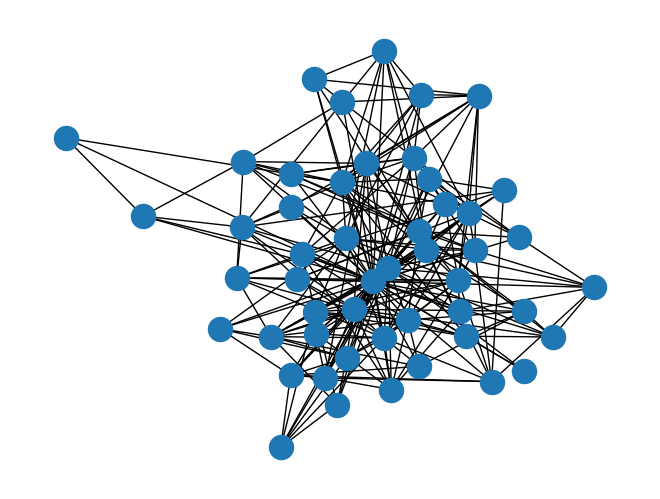

In [159]:
G = g

# 2. Get the degree for all nodes
# G.degree() returns a DegreeView of (node, degree) tuples
degree_items = list(G.degree())

# 3. Sort by degree (the second element of the tuple) in descending order
# we use key=lambda x: x[1] to tell Python to sort by the degree count
sorted_nodes = sorted(degree_items, key=lambda x: x[1], reverse=True)

# 4. Slice the top 50
top_50_nodes = sorted_nodes[:50]

# 5. Display the results
print(f"{'Node ID':<10} | {'Degree':<10}")
print("-" * 25)
for node, degree in top_50_nodes:
    print(f"{node:<10} | {degree:<10}")

# Optional: If you just want a list of the node IDs without the degree counts:
top_50_ids_only = [node for node, degree in top_50_nodes]

nx.draw(g.subgraph(top_50_ids_only))

In [42]:
with open('../data/uploaded/1/1.txt',encoding='utf-8') as f:
    book = f.read()
book[:100]

'\ufeff苟在初圣魔门当人材\n作者：鹤守月满池\n简介：\n简介：    苟在初圣魔门当人材简介：\n\u3000\u3000！\n第一章 百世书\n\u3000\u3000魔门，初圣宗。\n\u3000\u3000重重云海，波涛如怒，一座座景象万千的山峰就像是云海中的岛屿，星罗'

In [43]:
searcher = BookSearcher(book)

samples = sample_pairs(G_complete,100,100)

In [50]:
samples.keys()

dict_keys(['linked', 'non_linked', 'missing'])

In [59]:
missing = [(x[1:-1],y[1:-1]) for x,y in missing]
samples['missing']=[(x,y) for x,y in missing if (x not in y and y not in x)]

In [60]:
distances = {}
for key in samples.keys():
    distances[key] = []
    for n1,n2 in samples[key]:
        distances[key].append(searcher.closest_distance(n1,n2))

In [61]:
samples

{'linked': [('吕阳', '刘驰'),
  ('净土', '大罗汉(筑基后期大真人)'),
  ('广明', '宝瓶水月菩萨'),
  ('盘龙岛', '师尊（圣宗师尊）'),
  ('罗酆山', '茶亭（云气汇成）'),
  ('妙音真人', '祟应'),
  ('吕阳', '海外'),
  ('维摩陀尊者', '玄铁剑主'),
  ('天吴殿', '道庭天子/天吴皇族/天子'),
  ('重光真人', '阵法之灵'),
  ('幡灵陈信安', '幡灵陈信安'),
  ('鸿运道人', '宝曜福地'),
  ('骷髅山坊市', '北疆'),
  ('陈信安', '补天峰峰主'),
  ('清澄飞雪真君', '鸿举'),
  ('吕阳', '重光真人'),
  ('陈皓', '陈皓'),
  ('陈舒倩', '补天峰主'),
  ('维摩陀尊者', '维摩陀尊者'),
  ('吕阳', '罗酆山'),
  ('弟子(泛称)', '弟子(泛称)'),
  ('赵旭河', '飞霞仙子'),
  ('吕阳', '血衣楼'),
  ('骷髅山', '伏龙罗汉'),
  ('赵旭河', '善功楼 (善功/善功殿)'),
  ('铡龙关', '江北'),
  ('清澄飞雪真君', '血魔真人'),
  ('伏龙罗汉', '广明'),
  ('赵旭河', '盘龙真人'),
  ('吕阳', '巫鬼秘境'),
  ('凶魔（文中“那凶魔”）', '凶魔（文中“那凶魔”）'),
  ('本体陈信安', '本体陈信安'),
  ('赵旭河', '补天峰主'),
  ('多宝童子', '净土'),
  ('先天散人', '先天散人'),
  ('吕阳', '重光真人'),
  ('刘信', '刘信'),
  ('天京城', '魏家宅邸'),
  ('阴山真人', '昭夏氏老祖 夏未明'),
  ('吕阳', '若湘'),
  ('剑阁真君化身', '剑阁真君化身'),
  ('峰主', '峰主千金'),
  ('吕阳', '清澄飞雪真君'),
  ('江北', '玄剑山'),
  ('清澄飞雪真君', '缯彩绮罗真君'),
  ('盘龙岛', '盘龙真人'),
  ('重明', '徐鑫'),
  ('广海', '广明'),
  ('骷髅山', '巫鬼秘境'),
  ('飞霞'

In [62]:
distances

{'linked': [8,
  -1,
  8,
  -1,
  -1,
  21,
  3,
  9,
  -1,
  14,
  0,
  17,
  3,
  20,
  31,
  3,
  0,
  7,
  0,
  4,
  -1,
  4,
  5,
  8,
  -1,
  4,
  23,
  8,
  9,
  5,
  -1,
  0,
  4,
  12,
  0,
  3,
  0,
  4,
  -1,
  3,
  0,
  -1,
  5,
  58,
  11,
  29,
  3,
  3,
  7,
  0,
  18,
  -1,
  14,
  15,
  4,
  0,
  0,
  4,
  8,
  0,
  8,
  6,
  3,
  14,
  3,
  525,
  -1,
  0,
  -1,
  -1,
  7,
  9,
  4,
  9,
  5,
  0,
  7,
  -1,
  -1,
  8,
  5,
  5,
  4,
  4,
  8,
  -1,
  7,
  -1,
  3,
  6,
  3,
  5,
  -1,
  30,
  0,
  4,
  3,
  16,
  5,
  3],
 'non_linked': [-1,
  5307,
  -1,
  42500,
  -1,
  502230,
  97,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  38,
  219,
  -1,
  -1,
  -1,
  363379,
  -1,
  -1,
  203409,
  -1,
  -1,
  -1,
  -1,
  -1,
  -1,
  3533,
  -1,
  229094,
  -1,
  -1,
  -1,
  104319,
  371061,
  -1,
  -1,
  -1,
  51974,
  -1,
  -1,
  215401,
  -1,
  439266,
  -1,
  11987,
  -1,
  -1,
  -1,
  -1,
  141087,
  287,
  -1,
  -1,
  -1,
  181564,
  -1,
  6867,
  642,
  -1,
  -1,
  -1,
  -

In [34]:
graph['nodes'][21]

{'id': '神手谷',
 'name': '神手谷',
 'category': 'location',
 'symbolSize': 25,
 'properties': {'name': '神手谷',
  'chunk id': '8FqJYg1K',
  'schema_type': 'location'}}